In [213]:
import pandas as pd
import numpy as np
from dotenv import load_dotenv
import os
from typing import List, Tuple
import seaborn as sns

from tqdm import tqdm

import spacy as sp
import re
import emoji
from spacy.matcher import Matcher

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, f1_score, classification_report


from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import StrOutputParser
from langchain_core.messages import SystemMessage, HumanMessage

In [2]:
pd.set_option("max_colwidth", None)
df = pd.read_csv('Russian dataset for the reply recovery/final_complete/train_data.csv')
df.head()

,Unnamed: 0,premise,hypothesis,label,chat
0,0,И изи,А если третий?,1,terrariaphone
1,1,"хз, машина твоя подойдет я думаю",хааааа!!! ))) даж в проекте цобакенов на газонах выгуливают))),1,orange_sosedi
2,2,Лови,Всем похуй,1,terrariaphone
3,3,"Добрый день! Дочке 5 лет, не выговаривает звуки к-г и л. В логогруппу нас не взяли. Весной мы пошли к логопеду. Она категорически не хочет заниматься, грубит, вредничает, были у двух логопедов, так с обоими. И вообще есть особенность - любит хвастать, но если есть в чем-то милейшая трудность, дочка избегает такое дело. Что можно сделать в нашей ситуации. К-г и л к пяти годам уже должны были встать, и старшие дети во дворе бывает дразнятся. До пяти лет я по поводу звуков и не ""лезла"" к дочке",Ларец знаний. Как-то была реклама недавно что там бесплатный прием логопеда,0,sling38
4,4,"Я когда заезжала, думала что оп будет охраняемый) потому что сколько раз была в гостях в новостройках, чаще всего там была пропускная система. Потом уже выяснила)","Купили квартиру, не изучив проект? Вы смелая 😄",0,orange_sosedi


In [3]:
nlp = sp.load("ru_core_news_sm")

In [4]:
remove_start = {"а", "кстати", "то"}
negative_ptr = {"это", "там", "ты", "тут", "вот"}
negative_connectors = {"или", "и", "вы", "ну", "так", "да", "разве", "о"}
positive_words = {"подскажите", "подскажи", "ребят", "ребята", "коллеги", "друзья",
                  "кто-нибудь", "всем", "кто-то", "привет", "здравствуйте", "доброго"}
positive_combinations = { "если", "может", "я", "не", "можно", "в", "никто", "можете", "у" }
uncertain = {"на", "с", "интересно", "для", "мне"}
question_words = {"как", "что", "сколько", "где", "какой", "кто", "когда",
                  "почему", "чем", "чего", "куда", "который", "кому", "зачем",
                  "откуда", "чей", "чья", "каков", "отчего"}

pattern_esli_to = [{'LOWER': 'если'},
                        {'OP': '*'},
                        {'LOWER': 'то'}]

pattern_ya_verno = [{'LOWER': 'я'},
                        {'OP': '*'},
                        {'LOWER': 'верно'}]

pattern_ya_ponyal = [{'LOWER': 'я'},
                     {'OP': '*'},
                     {'LOWER': 'правильно'},
                     {'OP': '*'},
                     {'LEMMA': {'IN': ['понял', 'понимаю']}}]

pattern_v_etc = [{'LOWER': 'в'},
                 {'LOWER': {'IN': list(question_words)}}]

pattern_v_suffix = [{'LOWER': 'в'},
                    {'TEXT': {'REGEX': r'.*(их|ой|ом)$'}}]

pattern_nikto_ne = [{'LOWER': 'никто'},
                    {'OP': '*'},
                    {'LOWER': 'не'}]
pattern_mojet_kto_nibud = [{'LOWER': 'может'},
                           {'OP': '*'},
                           {'LOWER': {'IN': ['кто', 'кто-нибудь']}}]

pattern_u_kogo_nibud = [{'LOWER': 'у'},
                        {'OP': '*'},
                        {'LOWER': 'кого-нибудь'}]

pattern_mojno_li_uznat = [{'LOWER': 'можно'},
                        {'OP': '*'},
                        {'LOWER': {'IN': ['ли', 'узнать']}}]

pattern_ne_znaete_podskajite = [{'LOWER': 'не'},
                        {'OP': '*'},
                        {'LOWER': {'IN': ['знаете', 'подскажите']}}]

pattern_mojete = [{'LOWER': 'можете'}]


matcher = Matcher(nlp.vocab)
matcher.add('YA_PRAVILNO_PONYAL', [pattern_esli_to])
matcher.add('V_QUESTION_WORD', [pattern_ya_verno])
matcher.add('YA_PRAVILNO_PONYAL', [pattern_ya_ponyal])
matcher.add('V_QUESTION_WORD', [pattern_v_etc])
matcher.add('V_SUFFIX', [pattern_v_suffix])
matcher.add('NIKTO_NE', [pattern_nikto_ne])
matcher.add('MOJET_KTO_NIBUD', [pattern_mojet_kto_nibud])
matcher.add('U_KOGO_NIBUD', [pattern_u_kogo_nibud])
matcher.add('NIKTO_NE', [pattern_mojno_li_uznat])
matcher.add('MOJET_KTO_NIBUD', [pattern_ne_znaete_podskajite])
matcher.add('U_KOGO_NIBUD', [pattern_mojete])


def tokenize_text(text: str) -> List[str]:
    '''lowercase, tokenize and remove punctuation'''
    text = text.lower().strip()
    doc = nlp(text)
    tokens = [t.text for t in doc if not t.is_punct]
    return tokens, doc

def classify_questions(text: str) -> int:
    '''questions classification based on euristics'''

    tokens, doc = tokenize_text(text)

    matchers = matcher(doc)

    if not tokens:
        return 2

    first_token = tokens[0]

    if first_token in remove_start and len(tokens) > 1:
        first_token = tokens[1]


    if not tokens:
        return 2

    # 0 not informative
    if first_token in negative_ptr or first_token in negative_connectors: return 0

    if matchers: return 0

    # 1 informative + добавить обращение TODO
    if first_token in positive_words: return 1

    if first_token in question_words: return 1
    if any(q in tokens for q in question_words): return 1
    if first_token == "а" and len(tokens) > 1 and tokens[1] in question_words: return 1


    return 1


def classify_df(df: pd.DataFrame) -> pd.DataFrame:
    df["prediction"] = df["premise"].apply(classify_questions)
    return df

In [5]:
def sample_questions(df: pd.DataFrame, n: int=100) -> pd.DataFrame:

    # find premises with '?'
    mask = df["premise"].str.contains(r'\? ', regex=True, na=False)
    df_questions = df[mask].head(n).copy()
    # apply function
    df_questions = classify_df(df_questions)
    # form dataset + rename columns
    df_questions = df_questions[["premise", "prediction"]]
    df_questions = df_questions.rename(columns={"premise" : "question",
                                                "prediction" : "class"})
    return df_questions

In [6]:
df_sample = sample_questions(df, n=1000)

In [7]:
df_sample = df_sample.reset_index(drop=True)
df_sample['label'] = np.nan
df_sample.head()

,question,class,label
0,"Девушки, кто-нибудь подал на увеличение пособия 3-7 через госуслуги? Не могу найти там это заявление",1,NaN
1,"А вы первый раз подавали? Я повторно, просто",0,NaN
2,"Что вы тогда переживаете? У вас справка на руках. Если у вас хороший врач то вряд ли она вас выписала бы. Плюс да, через 7 дней вы вряд ли уже заразны)",0,NaN
3,"Победа, можно личный вопрос на публику? Даже два..",1,NaN
4,"Доброе утро,скажите,пожалуйста,а есть у нас в жк,кто помыть окна может? Поделитесь контактами,пожалуйста🙏🏻",1,NaN


In [8]:
class LLM_classifier:
    
    def __init__(self, model, API_KEY, SYSTEM_PROMPT, url):
        self.parser = StrOutputParser()
        self.model = model
        self.API_KEY = API_KEY
        self.SYSTEM_PROMPT = SYSTEM_PROMPT
        self.url = url
        
    def classify_question(self, llm, question) -> int:
        '''if incorrect response => rerun try to return 3 times if fails => -1'''
        for attempt in range(3):
            message = [SystemMessage(content=self.SYSTEM_PROMPT), HumanMessage(content=str(question))]
            llm_response = llm.invoke(message)
            raw = self.parser.invoke(llm_response).strip()
            try:
                label = int(raw)
            except ValueError:
                continue
            if label in (0, 1): return label
        return -1

    def classify_dataframe(self, df_final_labels, model_name) -> pd.DataFrame:
        result = pd.DataFrame()
        result['question'] = df_final_labels['question']

        llm = ChatOpenAI(api_key=self.API_KEY, base_url=self.url, model=model_name)
        labels = []
        for question in tqdm(df_final_labels['question'], desc=f'{model_name}'):
            label = self.classify_question(llm, question)
            labels.append(label)
            
        result[model_name] = labels
        return result

    def classify_dataframe_batches(self, df, model_name, batch_size=20) -> pd.DataFrame:
        '''process dataframe by batches, if fails => can restart where failed, bc update df directly.
           needs to have NaN column to put labels + check and retry logic'''
        llm = ChatOpenAI(api_key=self.API_KEY, base_url=self.url, model=model_name)
        n = len(df)
        try:
            for start in range(0, n, batch_size):
                end = min(start + batch_size, n)
                batch_df = df.iloc[start:end]
            
                for idx, question in tqdm(batch_df['question'].items(), total=len(batch_df), desc=f'{model_name} batch {start} - {end}'):
                    if pd.notna(df.at[idx, 'label']): continue
                    label = self.classify_question(llm, question)
                    df.at[idx, 'label'] = label
                    
        except KeyboardInterrupt:
            print('manual interrupt, return processed dataframe only')
            return df
            
        return df

In [9]:
SYSTEM_POMPT_CONTEXT = '''Ты — классификатор вопросов. Твоя задача: определить, является ли вопрос ИНФОРМАТИВНЫМ (1) или НЕИНФОРМАТИВНЫМ (0).

Верни строго одно число:
1 — информативный вопрос  
0 — неинформативный вопрос  

ОПРЕДЕЛЕНИЯ:

ИНФОРМАТИВНЫЙ ВОПРОС — это вопрос, цель которого восполнить недостающие знания с помощью общеизвестных фактов. Такой вопрос:
- имеет чёткую цель восполнить недостающие знания по определенной теме фактами;
- запрашивает факты, информацию, опыт, инструкции, правила, контакты, местоположение, цены, процедуры;
- имеет широкий контекст: касается большой группы людей, значимой локации, длительного периода времени или общих знаний;
- ответ на него может быть полезен кому‑то ещё, помимо автора.

НЕИНФОРМАТИВНЫЙ ВОПРОС — это вопрос, который НЕ направлен на получение новой полезной информации. Такой вопрос:
- имеет короткий, узкий или личный контекст;
- неясен или непонятно, о чём речь;
- выражает эмоцию, поддерживает разговор, уточняет детали предыдущего сообщения (дознавательный вопрос);
- риторический, саркастический, шуточный;
- не несёт ценности вне конкретного диалога.

ЭВРИСТИКА:
Задай себе вопрос: «Может ли ответ на этот вопрос быть полезен кому‑то ещё?»  
Если да — скорее всего, вопрос информативный.  
Если нет — скорее всего, неинформативный.

НЕСКОЛЬКО ВОПРОСОВ В СООБЩЕНИИ:
Если хотя бы один из вопросов информативный — ставь класс 1.

Примеры ИНФОРМАТИВНЫХ вопросов

- «Девушки, подскажите магазины, где посмотреть кроватку ребёнку, после колыбельки которая. После 2 х лет”»
- «Я очень хочу сделать маникюр за 1 мил / 5 300 ₽ ну очень , как записаться ?»
- «Девушки, кто-нибудь подал на увеличение пособия 3-7 через госуслуги? Не могу найти там это заявление»
- «девочки,где купить морепродуктов свежих рядом с Убудом?»
- «Доброе утро,скажите,пожалуйста,а есть у нас в жк,кто помыть окна может? Поделитесь контактами,пожалуйста»
- «А раньше трава покачивалась?»
- «Девочки, ОПЦ до декабря был на ремонте, кто-нибудь в курсе что именно там отремонтировали?)))»
- «Девочки!Подскажите,где можно купить типичные плетёные круглые сумки по закупочной цене?может кто находил около 100 -120 тыс?хочу несколько купить на сувениры подругам)И такой же вопрос про кокосовое масло.»
- «Привет, девочки!\nЕсть тут фотограф и оператор? Нужны для семейной фотосессии»
- «А для Порчи какой лучше класс?»
- «Если подавали в мфц котельники ,в видном будут документы ?»
- «Может кто подсказать, как дойти до метро?»
- «Всем привет, недавно приехали с мужем в этот замечательный город и не можем найти рынок с продуктами, может подсказать, где его найти?»

Примеры НЕИНФОРМАТИВНЫХ вопросов

- «Я могу написать тебе в лс?» — касается только двух людей.
- «Вам таблетки или травы?» — дознавательный вопрос.
- «А зачем это строить?» — непонятно, о чём речь, дознавательный вопрос.
- «А вы первый раз подавали? Я повторно, просто» — дознавательный вопрос.
- «Бюрки где?» — неясно, о чём идёт речь.
- «А под что маскировать?» — дознавательный вопрос.
- «А микрот туда запилить нельзя?» — недостаточно контекста («туда» — куда?).
- «Рей или Каору?» — опрос мнения.
- «да нефтепродукты это, вы на заправке никогда не были? бензином краску с одежды никогда не смывали?» — саркастичный вопрос.
- «Ну как вам сегодня погода?» — короткий контекст, информация быстро устаревает.
- «Какже хорошо, да?» — продолжение разговора.
- «А во сколько они работают?» — недостаточно контекста («они» — кто?).
- «Спасибо, а что скажете по отоплению, холодно? Угловая квартира всё‑таки.» — неясно, о каком месте речь.

ФОРМАТ ОТВЕТА:
Верни только одно число: 0 или 1.
Никаких пояснений, текста или комментариев.
'''

In [10]:
model = 'qwen3-14b'
load_dotenv()
API_KEY = os.getenv("API_KEY")
url = 'https://bothub.chat/api/v2/openai/v1'

classifier = LLM_classifier(model, API_KEY, SYSTEM_POMPT_CONTEXT, url)

In [11]:
df_sample = classifier.classify_dataframe_batches(df_sample, model, batch_size=50)

qwen3-14b batch 950 - 1000: 100%|███████████████| 50/50 [11:53<00:00, 14.27s/it]


In [14]:
df_sample.head()

,question,class,label
0,"Девушки, кто-нибудь подал на увеличение пособия 3-7 через госуслуги? Не могу найти там это заявление",1,1.0
1,"А вы первый раз подавали? Я повторно, просто",0,0.0
2,"Что вы тогда переживаете? У вас справка на руках. Если у вас хороший врач то вряд ли она вас выписала бы. Плюс да, через 7 дней вы вряд ли уже заразны)",0,0.0
3,"Победа, можно личный вопрос на публику? Даже два..",1,0.0
4,"Доброе утро,скажите,пожалуйста,а есть у нас в жк,кто помыть окна может? Поделитесь контактами,пожалуйста🙏🏻",1,1.0


In [256]:
df_sample.to_csv('df_sample.csv', index=False)

## Data preprocessing and Classification

In [259]:
df_sample['label'].unique()

array([1, 0])

In [261]:
df_sample['label'] = df_sample['label'].astype('int64')

In [263]:
df_sample_clean = df_sample.copy()
df_sample_clean['question'] = df_sample_clean['question'].apply(lambda x : emoji.replace_emoji(x, ''))
df_sample_clean

,question,class,label
0,"Девушки, кто-нибудь подал на увеличение пособия 3-7 через госуслуги? Не могу найти там это заявление",1,1
1,"А вы первый раз подавали? Я повторно, просто",0,0
2,"Что вы тогда переживаете? У вас справка на руках. Если у вас хороший врач то вряд ли она вас выписала бы. Плюс да, через 7 дней вы вряд ли уже заразны)",0,0
3,"Победа, можно личный вопрос на публику? Даже два..",1,0
4,"Доброе утро,скажите,пожалуйста,а есть у нас в жк,кто помыть окна может? Поделитесь контактами,пожалуйста",1,1
...,...,...,...
995,18.06.7? Блеать,1,0
996,Почему не должен? Я вроде не слышал ничего,1,0
997,"Интересно очень, сколько платите? Сколько занятий в неделю? В какое время?",1,0
998,"Девочки,перед д/садом ,что сдают соскоб или кал на я/г? Мне сказали соскоб,а подружка идет в эту же группу им кал.",1,1


In [264]:
vectorizer = CountVectorizer(analyzer='word')
X = vectorizer.fit_transform(df_sample_clean['question'])
y = df_sample_clean['label']

log_reg = LogisticRegression(penalty='l2', C=1.0, random_state=42, solver='lbfgs', max_iter=1000)
log_reg.fit(X, y)

LogisticRegression(max_iter=1000, random_state=42)

In [266]:
df_test = pd.read_csv('data/gold_manual_anno.csv')
X_test, y_test = df_test['question'], df_test['final']
X_test = df_test['question'].apply(lambda x : emoji.replace_emoji(x, ''))

X_test = vectorizer.transform(X_test)
y_pred = log_reg.predict(X_test)

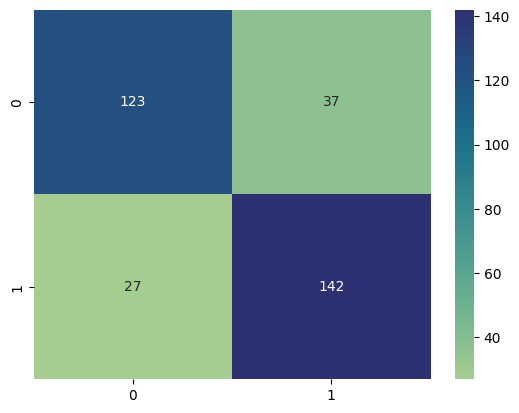

In [269]:
matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(matrix, cmap='crest', annot=True, fmt='d');

In [271]:
f1_classification = f1_score(y_test, y_pred, average='macro')
f1_classification

0.8048201705598814

In [273]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.77      0.79       160
           1       0.79      0.84      0.82       169

    accuracy                           0.81       329
   macro avg       0.81      0.80      0.80       329
weighted avg       0.81      0.81      0.81       329

